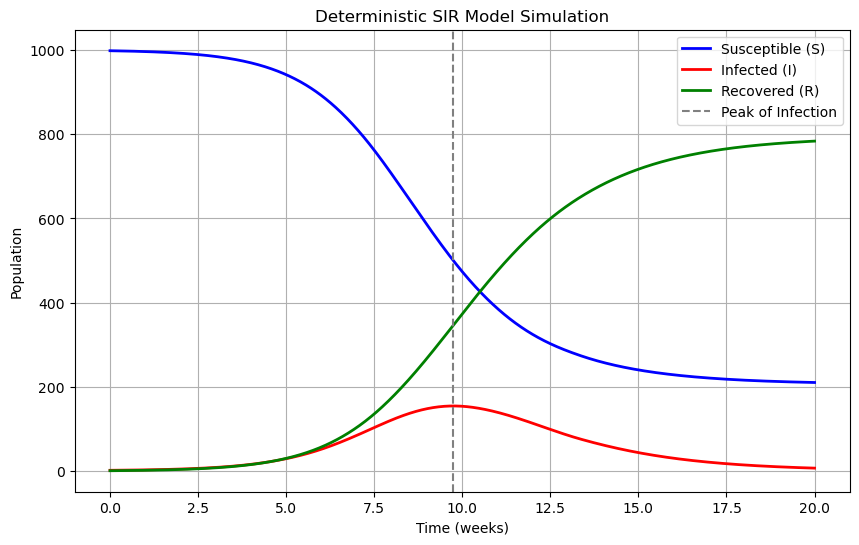

In [34]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

a = 2 * np.log(2)  #Infection rate
b = np.log(2)      #Recovery rate 
N = 1000           #Total population

def sir_model(t, y):
    S, I, R = y
    dSdt = - (a / N) * I * S
    dIdt = (a / N) * I * S - b * I
    dRdt = b * I
    return [dSdt, dIdt, dRdt]

y0 = [999, 1, 0]
t_span = (0, 20)   #Time interval
t_eval = np.linspace(0, 20, 1000)

solution = solve_ivp(sir_model, t_span, y0, t_eval=t_eval)

plt.figure(figsize=(10, 6))
plt.plot(solution.t, solution.y[0], label='Susceptible (S)', color='blue', linewidth=2)
plt.plot(solution.t, solution.y[1], label='Infected (I)', color='red', linewidth=2)
plt.plot(solution.t, solution.y[2], label='Recovered (R)', color='green', linewidth=2)
plt.axvline(x=solution.t[np.argmax(solution.y[1])], color='gray', linestyle='--', label='Peak of Infection')
plt.xlabel('Time (weeks)')
plt.ylabel('Population')
plt.title('Deterministic SIR Model Simulation')
plt.legend()
plt.grid(True)
plt.show()

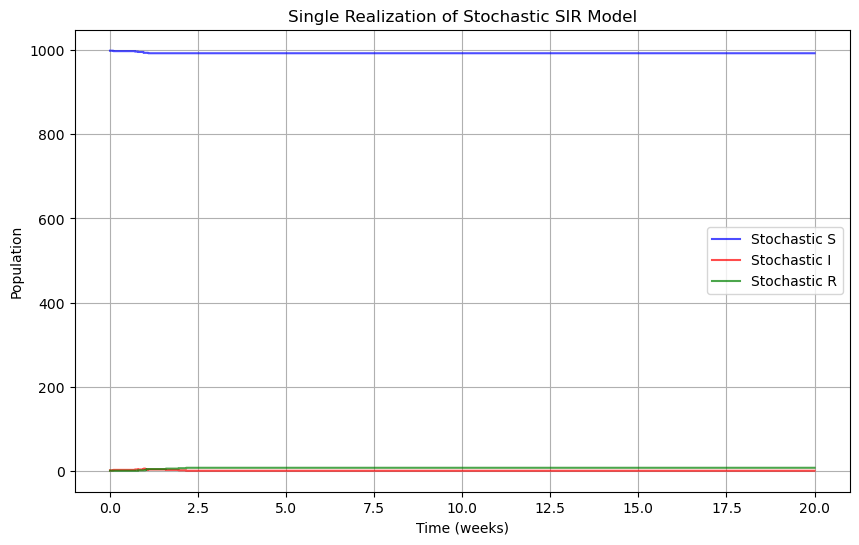

In [35]:
import numpy as np
import matplotlib.pyplot as plt

a = 2 * np.log(2)
b = np.log(2)
N = 1000
h = 0.001  #Small time step
t_max = 20
num_steps = int(t_max / h)

t = np.linspace(0, t_max, num_steps)
S = np.zeros(num_steps)
I = np.zeros(num_steps)
R = np.zeros(num_steps)

S[0], I[0], R[0] = 999, 1, 0

for k in range(0, num_steps - 1):
    S_curr, I_curr, R_curr = S[k], I[k], R[k]
    
    P_inf = (a / N) * I_curr * S_curr * h
    P_rec = b * I_curr * h
    
    u = np.random.rand()
    
    if u < P_inf and S_curr > 0:
        S[k+1] = S_curr - 1
        I[k+1] = I_curr + 1
        R[k+1] = R_curr
    elif u < (P_inf + P_rec) and I_curr > 0:
        S[k+1] = S_curr
        I[k+1] = I_curr - 1
        R[k+1] = R_curr + 1
    else:
        S[k+1] = S_curr
        I[k+1] = I_curr
        R[k+1] = R_curr


plt.figure(figsize=(10, 6))
plt.plot(t, S, label='Stochastic S', color='blue', alpha=0.7)
plt.plot(t, I, label='Stochastic I', color='red', alpha=0.7)
plt.plot(t, R, label='Stochastic R', color='green', alpha=0.7)
plt.xlabel('Time (weeks)')
plt.ylabel('Population')
plt.title('Single Realization of Stochastic SIR Model')
plt.legend()
plt.grid(True)
plt.show()

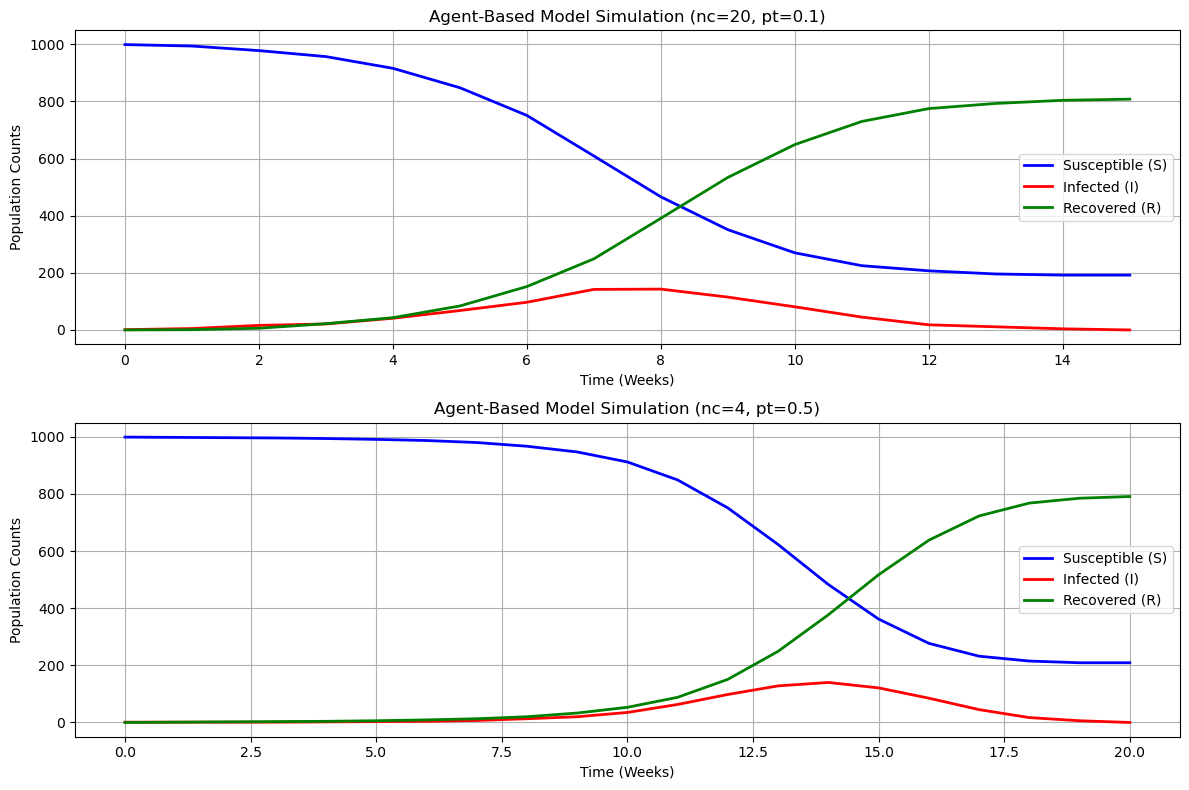

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def initial1D(s0, i0, r0):
    """
    Sets an initial population array for the epidemic simulation.
    Equivalent to initial1D.m
    """
    pop = []
    pop.extend(['s'] * s0)
    pop.extend(['i'] * i0)
    pop.extend(['r'] * r0)
    return np.array(pop, dtype=object)

def census1D(pop):
    """
    Counts the number of 's', 'i', and 'r' cells in pop.
    Equivalent to census1D.m
    """
    s = np.sum(pop == 's')
    i = np.sum(pop == 'i')
    r = np.sum(pop == 'r')
    return s, i, r

def epidemic1D(nc, pt, pop1):
    """
    Stochastic epidemic simulation calculating a new population state.
    Equivalent to epidemic1D.m
    """
    pop2 = pop1.copy()  # set up new vector
    n = len(pop1)
    
    for j in range(n):
        if pop1[j] == 'i':
            for c in range(nc):  # nc contacts
                k = j
                while k == j:  # try to generate a random k NOT equal to j
                    k = np.random.randint(0, n)  # random individual to contact (0-indexed)
                
                # If the contacted individual is susceptible, infect them with probability pt
                if pop1[k] == 's' and np.random.rand() < pt:
                    pop2[k] = 'i'  # infect the 's' cell
            
            pop2[j] = 'r'  # then the j-th individual recovers
            
    return pop2

def simulate1D(n, nc, pt):
    """
    Packages the entire simulation steps until I=0.
    Equivalent to simulate1D.m
    """
    t = 0
    pop = initial1D(n, 0, 0)       # set up an initial population of susceptibles
    pop[int(np.floor(n / 2))] = 'i'  # put an infected individual in the middle
    
    s, i, r = census1D(pop)
    results = [[s, i, r]]          # start the results tracking list
    tt = [t]
    
    while i > 0:
        pop = epidemic1D(nc, pt, pop)
        s, i, r = census1D(pop)
        results.append([s, i, r])
        t += 1
        tt.append(t)
        
    return np.array(tt), np.array(results)

N_population = 1000

timeA, resultsA = simulate1D(N_population, 20, 0.1)
timeB, resultsB = simulate1D(N_population, 4, 0.5)

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(timeA, resultsA[:, 0], 'b-', label='Susceptible (S)', linewidth=2)
plt.plot(timeA, resultsA[:, 1], 'r-', label='Infected (I)', linewidth=2)
plt.plot(timeA, resultsA[:, 2], 'g-', label='Recovered (R)', linewidth=2)
plt.title('Agent-Based Model Simulation (nc=20, pt=0.1)')
plt.xlabel('Time (Weeks)')
plt.ylabel('Population Counts')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(timeB, resultsB[:, 0], 'b-', label='Susceptible (S)', linewidth=2)
plt.plot(timeB, resultsB[:, 1], 'r-', label='Infected (I)', linewidth=2)
plt.plot(timeB, resultsB[:, 2], 'g-', label='Recovered (R)', linewidth=2)
plt.title('Agent-Based Model Simulation (nc=4, pt=0.5)')
plt.xlabel('Time (Weeks)')
plt.ylabel('Population Counts')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()